# <b>Headings</b>

1.[Importing Libraries](#import)
2.[Data Reading](#reading)
3.[Data Wrangling](#DataWrangling)
4.[CatBoostModel](#CatBoostModel)

## <font color="green"> Importing Libraries</font> <a class="anchor" id="import"></a>

In [4]:
import numpy as np
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"]=(16,6)

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tqdm import tqdm

import catboost as cb

# <font color="green"> Reading Data </font><a class="anchor" id="reading"></a>

In [7]:
df=pd.read_csv("PUBG_Game_Prediction_data.csv")

In [8]:
df.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0,0.0000,0,0.00,0,0,161.80,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0,0.0000,0,0.00,0,0,202.70,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0,0.0000,0,0.00,0,0,49.75,2,0,0.1875


In [11]:
df.shape

(4446966, 29)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          int64  
 4   boosts           int64  
 5   damageDealt      float64
 6   DBNOs            int64  
 7   headshotKills    int64  
 8   heals            int64  
 9   killPlace        int64  
 10  killPoints       int64  
 11  kills            int64  
 12  killStreaks      int64  
 13  longestKill      float64
 14  matchDuration    int64  
 15  matchType        object 
 16  maxPlace         int64  
 17  numGroups        int64  
 18  rankPoints       int64  
 19  revives          int64  
 20  rideDistance     float64
 21  roadKills        int64  
 22  swimDistance     float64
 23  teamKills        int64  
 24  vehicleDestroys  int64  
 25  walkDistance     float64
 26  weaponsAcquired  int64  
 27  winPoints   

# <b>Data Descritption </b>
#### DBNOs - Number of enemy players knocked.
#### assists - Number of enemy players this player damaged that were killed by teammates.
#### boosts - Number of boost items used.
#### damageDealt - Total damage dealt. Note: Self inflicted damage is subtracted.
#### headshotKills - Number of enemy players killed with headshots.
#### heals - Number of healing items used.
#### Id - Player’s Id
#### killPlace - Ranking in match of number of enemy players killed.
#### killPoints - Kills-based external ranking of player. (Think of this as an Elo ranking where only kills matter.) If there is a value other than -1 in rankPoints, then any 0 in killPoints should be treated as a “None”.
#### killStreaks - Max number of enemy players killed in a short amount of time.
#### kills - Number of enemy players killed.
#### longestKill - Longest distance between player and player killed at time of death. This may be misleading, as downing a player and driving away may lead to a large longestKill stat.
#### matchDuration - Duration of match in seconds.
#### matchId - ID to identify match. There are no matches that are in both the training and testing set.
#### matchType - String identifying the game mode that the data comes from. The standard modes are “solo”, “duo”, “squad”, “solo-fpp”, “duo-fpp”, and “squad-fpp”; other modes are from events or custom matches.
#### rankPoints - Elo-like ranking of player. This ranking is inconsistent and is being deprecated in the API’s next version, so use with caution. Value of       -1 takes place of “None”.
#### revives - Number of times this player revived teammates.
#### rideDistance - Total distance traveled in vehicles measured in meters.
#### roadKills - Number of kills while in a vehicle.
#### swimDistance - Total distance traveled by swimming measured in meters.
#### teamKills - Number of times this player killed a teammate.
#### vehicleDestroys - Number of vehicles destroyed.
#### walkDistance - Total distance traveled on foot measured in meters.-
#### weaponsAcquired - Number of weapons picked up.
#### winPoints - Win-based external ranking of player. (Think of this as an Elo ranking where only winning matters.) If there is a value other than -1 in rankPoints, then any 0 in winPoints should be treated as a “None”.
#### groupId - ID to identify a group within a match. If the same group of players plays in different matches, they will have a different groupId each time.
#### numGroups - Number of groups we have data for in the match.
#### maxPlace - Worst placement we have data for in the match. This may not match with numGroups, as sometimes the data skips over placements.
#### winPlacePerc - The target of prediction. This is a percentile winning placement, where 1 corresponds to 1st place, and 0 corresponds to last place in the match. It is calculated off of maxPlace, not numGroups, so it is possible to have missing chunks in a match.

# <font color="green">Data Wrangling</font><a class="anchor" id="DataWrangling">

## Checking for missing win prediction value

In [18]:
df[df["winPlacePerc"].isnull()]

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
2744604,f70c74418bb064,12dfbede33f92b,224a123c53e008,0,0,0.0,0,0,0,1,...,0,0.0,0,0.0,0,0,0.0,0,0,NaN


In [20]:
df.drop(2744604,inplace=True)

### Understanding player distribution in game

In [23]:
df["Playersjoined"]=df.groupby('matchId')["matchId"].transform('count')

In [25]:
df.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc,Playersjoined
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.00,0,0,0,60,...,0.0000,0,0.00,0,0,244.80,1,1466,0.4444,96
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.47,0,0,0,57,...,0.0045,0,11.04,0,0,1434.00,5,0,0.6400,91
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.00,0,0,0,47,...,0.0000,0,0.00,0,0,161.80,2,0,0.7755,98
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.90,0,0,0,75,...,0.0000,0,0.00,0,0,202.70,3,0,0.1667,91
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.00,0,0,0,45,...,0.0000,0,0.00,0,0,49.75,2,0,0.1875,97


In [ ]:
sns.countplot(df[df["Playersjoined"]>=75]["Playersjoined"])
plt.show()

## Analysing Data

#### 1.kills without moving

In [29]:
df["totaldist"]=df['rideDistance']+df['walkDistance']+df['swimDistance']

df["killwithoutmoving"]=((df["kills"]>0) & (df["totaldist"]==0))

In [31]:
df[df["killwithoutmoving"]==True].head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc,Playersjoined,totaldist,killwithoutmoving
1824,b538d514ef2476,0eb2ce2f43f9d6,35e7d750e442e2,0,0,593.0,0,0,3,18,...,0.0,0,0,0.0,8,0,0.8571,58,0.0,True
6673,6d3a61da07b7cb,2d8119b1544f87,904cecf36217df,2,0,346.6,0,0,6,33,...,0.0,0,0,0.0,22,0,0.6000,42,0.0,True
11892,550398a8f33db7,c3fd0e2abab0af,db6f6d1f0d4904,2,0,1750.0,0,4,5,3,...,0.0,0,0,0.0,13,0,0.8947,21,0.0,True
14631,58d690ee461e9d,ea5b6630b33d67,dbf34301df5e53,0,0,157.8,0,0,0,69,...,0.0,0,0,0.0,7,1500,0.0000,73,0.0,True
15591,49b61fc963d632,0f5c5f19d9cc21,904cecf36217df,0,0,100.0,0,1,0,37,...,0.0,0,0,0.0,10,0,0.3000,42,0.0,True


In [33]:
df[df["killwithoutmoving"]==True].shape

(1535, 32)

In [35]:
df[df["killwithoutmoving"]==True].index

Index([   1824,    6673,   11892,   14631,   15591,   20881,   23298,   24640,
         25659,   30079,
       ...
       4426500, 4429697, 4432954, 4436511, 4437516, 4440232, 4440898, 4440927,
       4441511, 4446682],
      dtype='int64', length=1535)

#### dropping the mods

In [38]:
df.drop(df[df["killwithoutmoving"]==True].index, inplace=True)

#### 2.Extra Ordinary Road Kills

In [41]:
df[df["roadKills"]>5].shape

(46, 32)

In [43]:
df.drop(df[df["roadKills"]>5].index,inplace=True)

#### 3.So many Kills HOW?

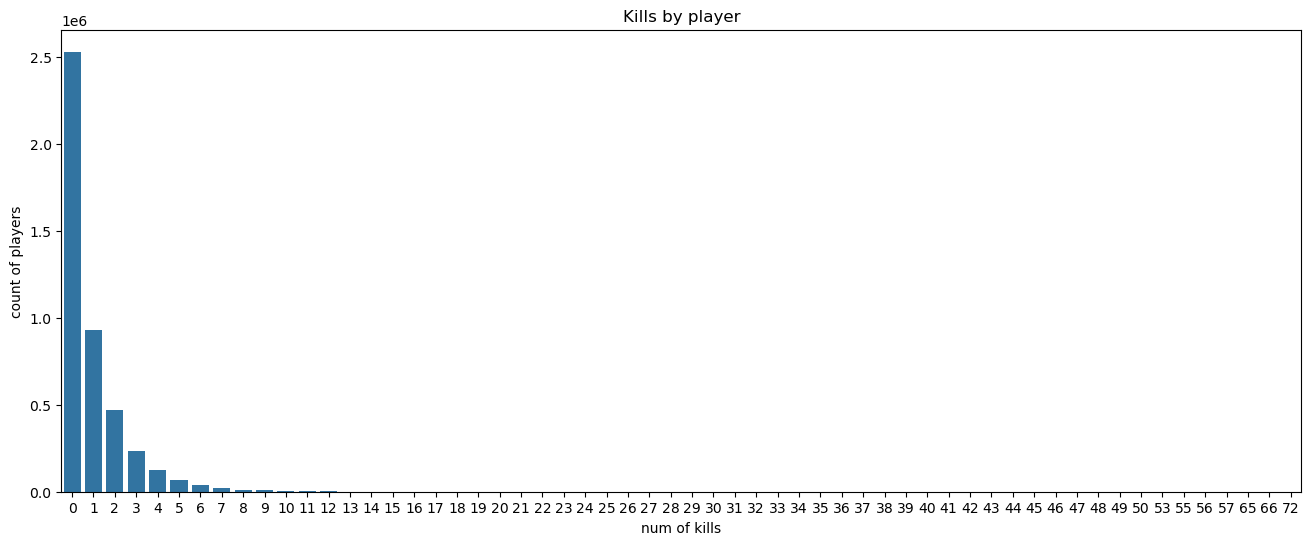

In [46]:
sns.countplot(data=df,x=df["kills"]).set_title("Kills by player")
plt.ylabel("count of players")
plt.xlabel("num of kills")
plt.show()

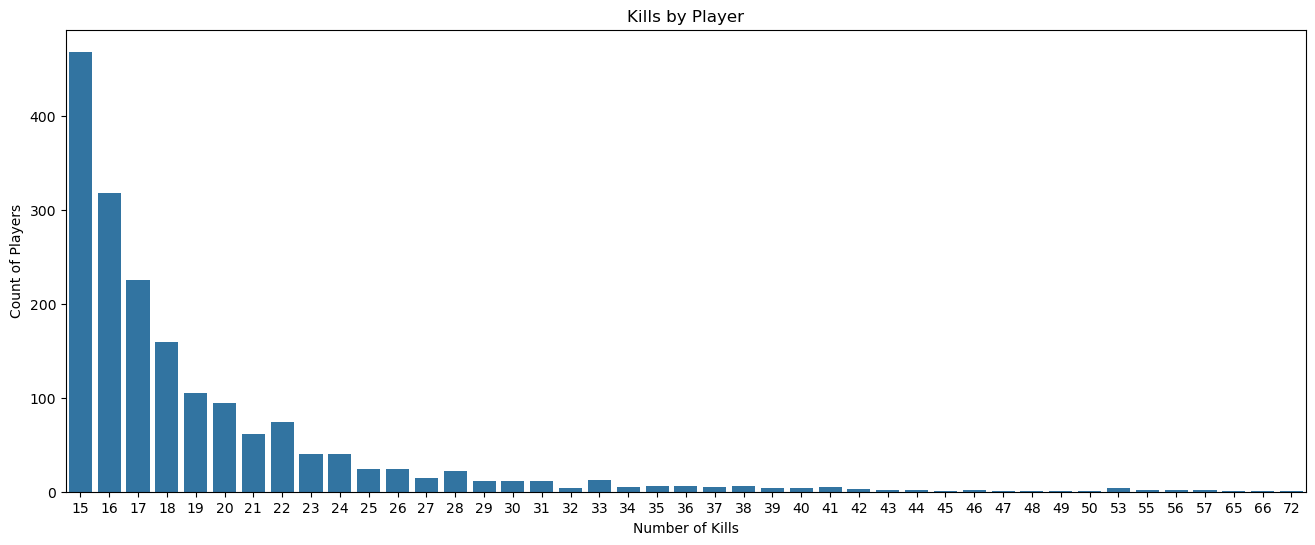

In [47]:
kills_count = df[df["kills"] >= 15]["kills"].value_counts().sort_index()
sns.barplot(x=kills_count.index, y=kills_count.values).set_title("Kills by Player")
plt.ylabel("Count of Players")
plt.xlabel("Number of Kills")
plt.show()


In [50]:
df[df["kills"]>20].shape

(417, 32)

In [52]:
df.drop(df[df["kills"]>20].index,inplace=True)

#### 4.HeadShot

In [54]:
df["headshotrate"]=df["headshotKills"]/df["kills"]
df["headshotrate"]=df["headshotrate"].fillna(0)

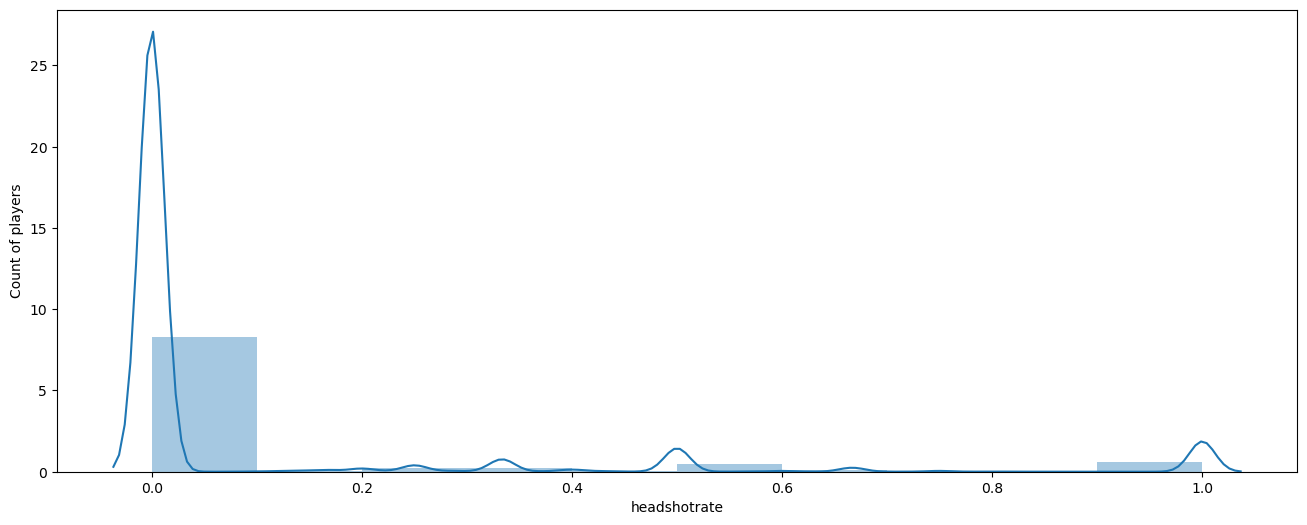

In [57]:
sns.distplot(df["headshotrate"],bins=10).set_title=("Headshot_Rate")
plt.ylabel("Count of players")
plt.show()

In [58]:
df[(df["headshotrate"]==1) & (df["kills"]>5)].shape

(187, 33)

In [59]:
df.drop(df[(df["headshotrate"]==1) & (df["kills"]>5)].index,inplace=True)

#### 6.Longest Shot

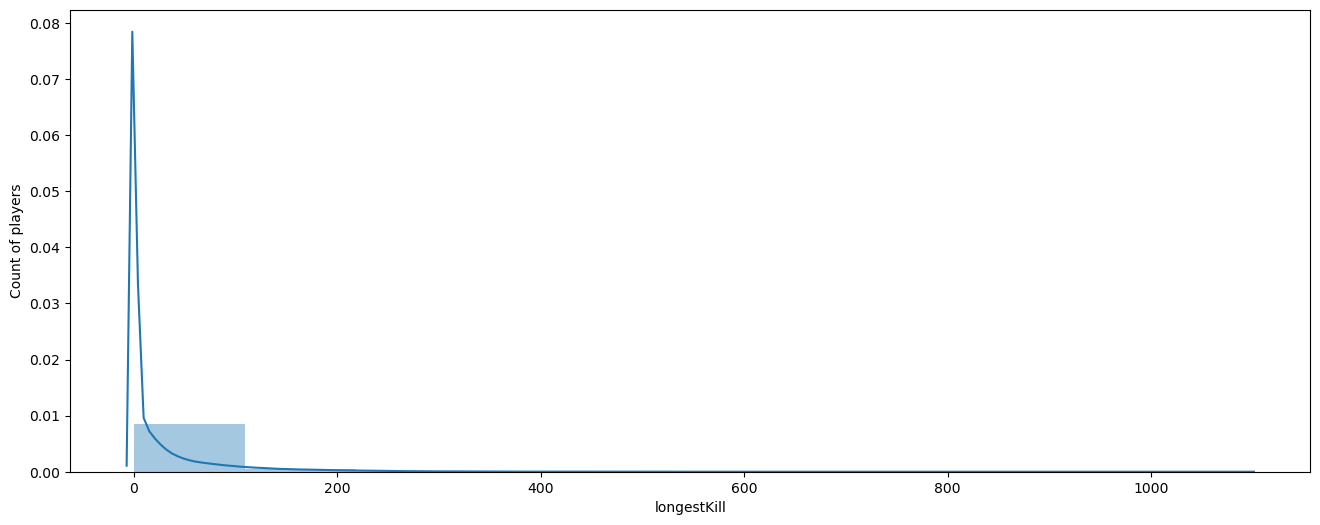

In [61]:
sns.distplot(df["longestKill"],bins=10).set_title=("Longest_kill")
plt.ylabel("Count of players")
plt.show()

In [62]:
df[df["longestKill"]>=500].shape

(1738, 33)

In [66]:
df.drop(df[df["headshotrate"]>=500].index,inplace=True)

#### 7.Weapon Change

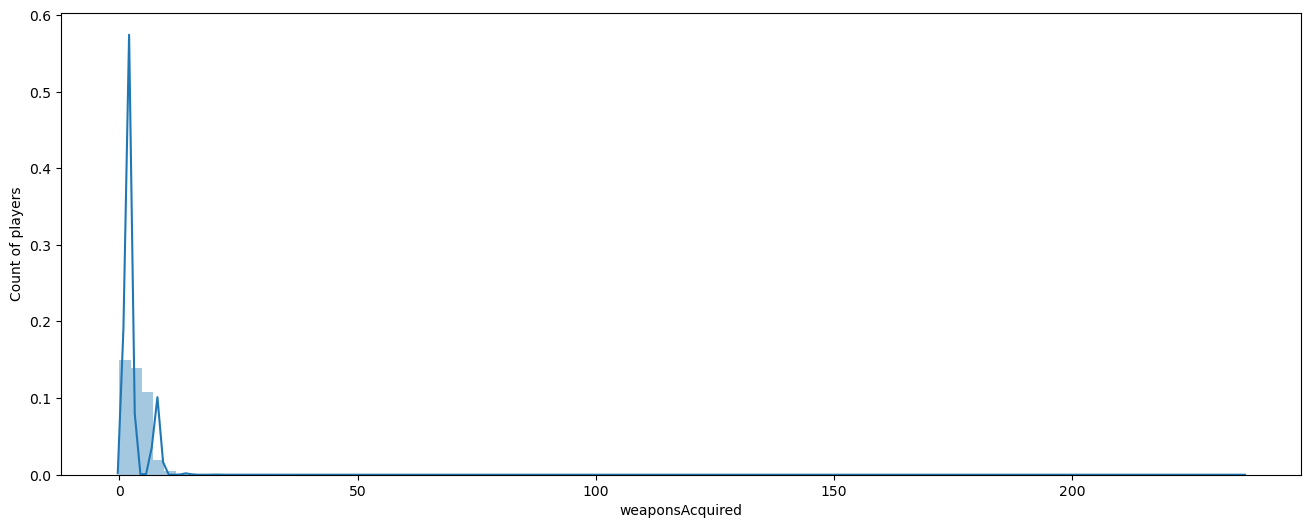

In [68]:
sns.distplot(df["weaponsAcquired"],bins=100).set_title=("Weapon_Chng")
plt.ylabel("Count of players")
plt.show()

In [72]:
df[df["weaponsAcquired"]>=15].shape

(6840, 33)

In [73]:
df.drop(df[df["weaponsAcquired"]>=15].index,inplace=True)

# EDA

In [75]:
df.shape

(4437940, 33)

In [76]:
df.isna().sum()

Id                   0
groupId              0
matchId              0
assists              0
boosts               0
damageDealt          0
DBNOs                0
headshotKills        0
heals                0
killPlace            0
killPoints           0
kills                0
killStreaks          0
longestKill          0
matchDuration        0
matchType            0
maxPlace             0
numGroups            0
rankPoints           0
revives              0
rideDistance         0
roadKills            0
swimDistance         0
teamKills            0
vehicleDestroys      0
walkDistance         0
weaponsAcquired      0
winPoints            0
winPlacePerc         0
Playersjoined        0
totaldist            0
killwithoutmoving    0
headshotrate         0
dtype: int64

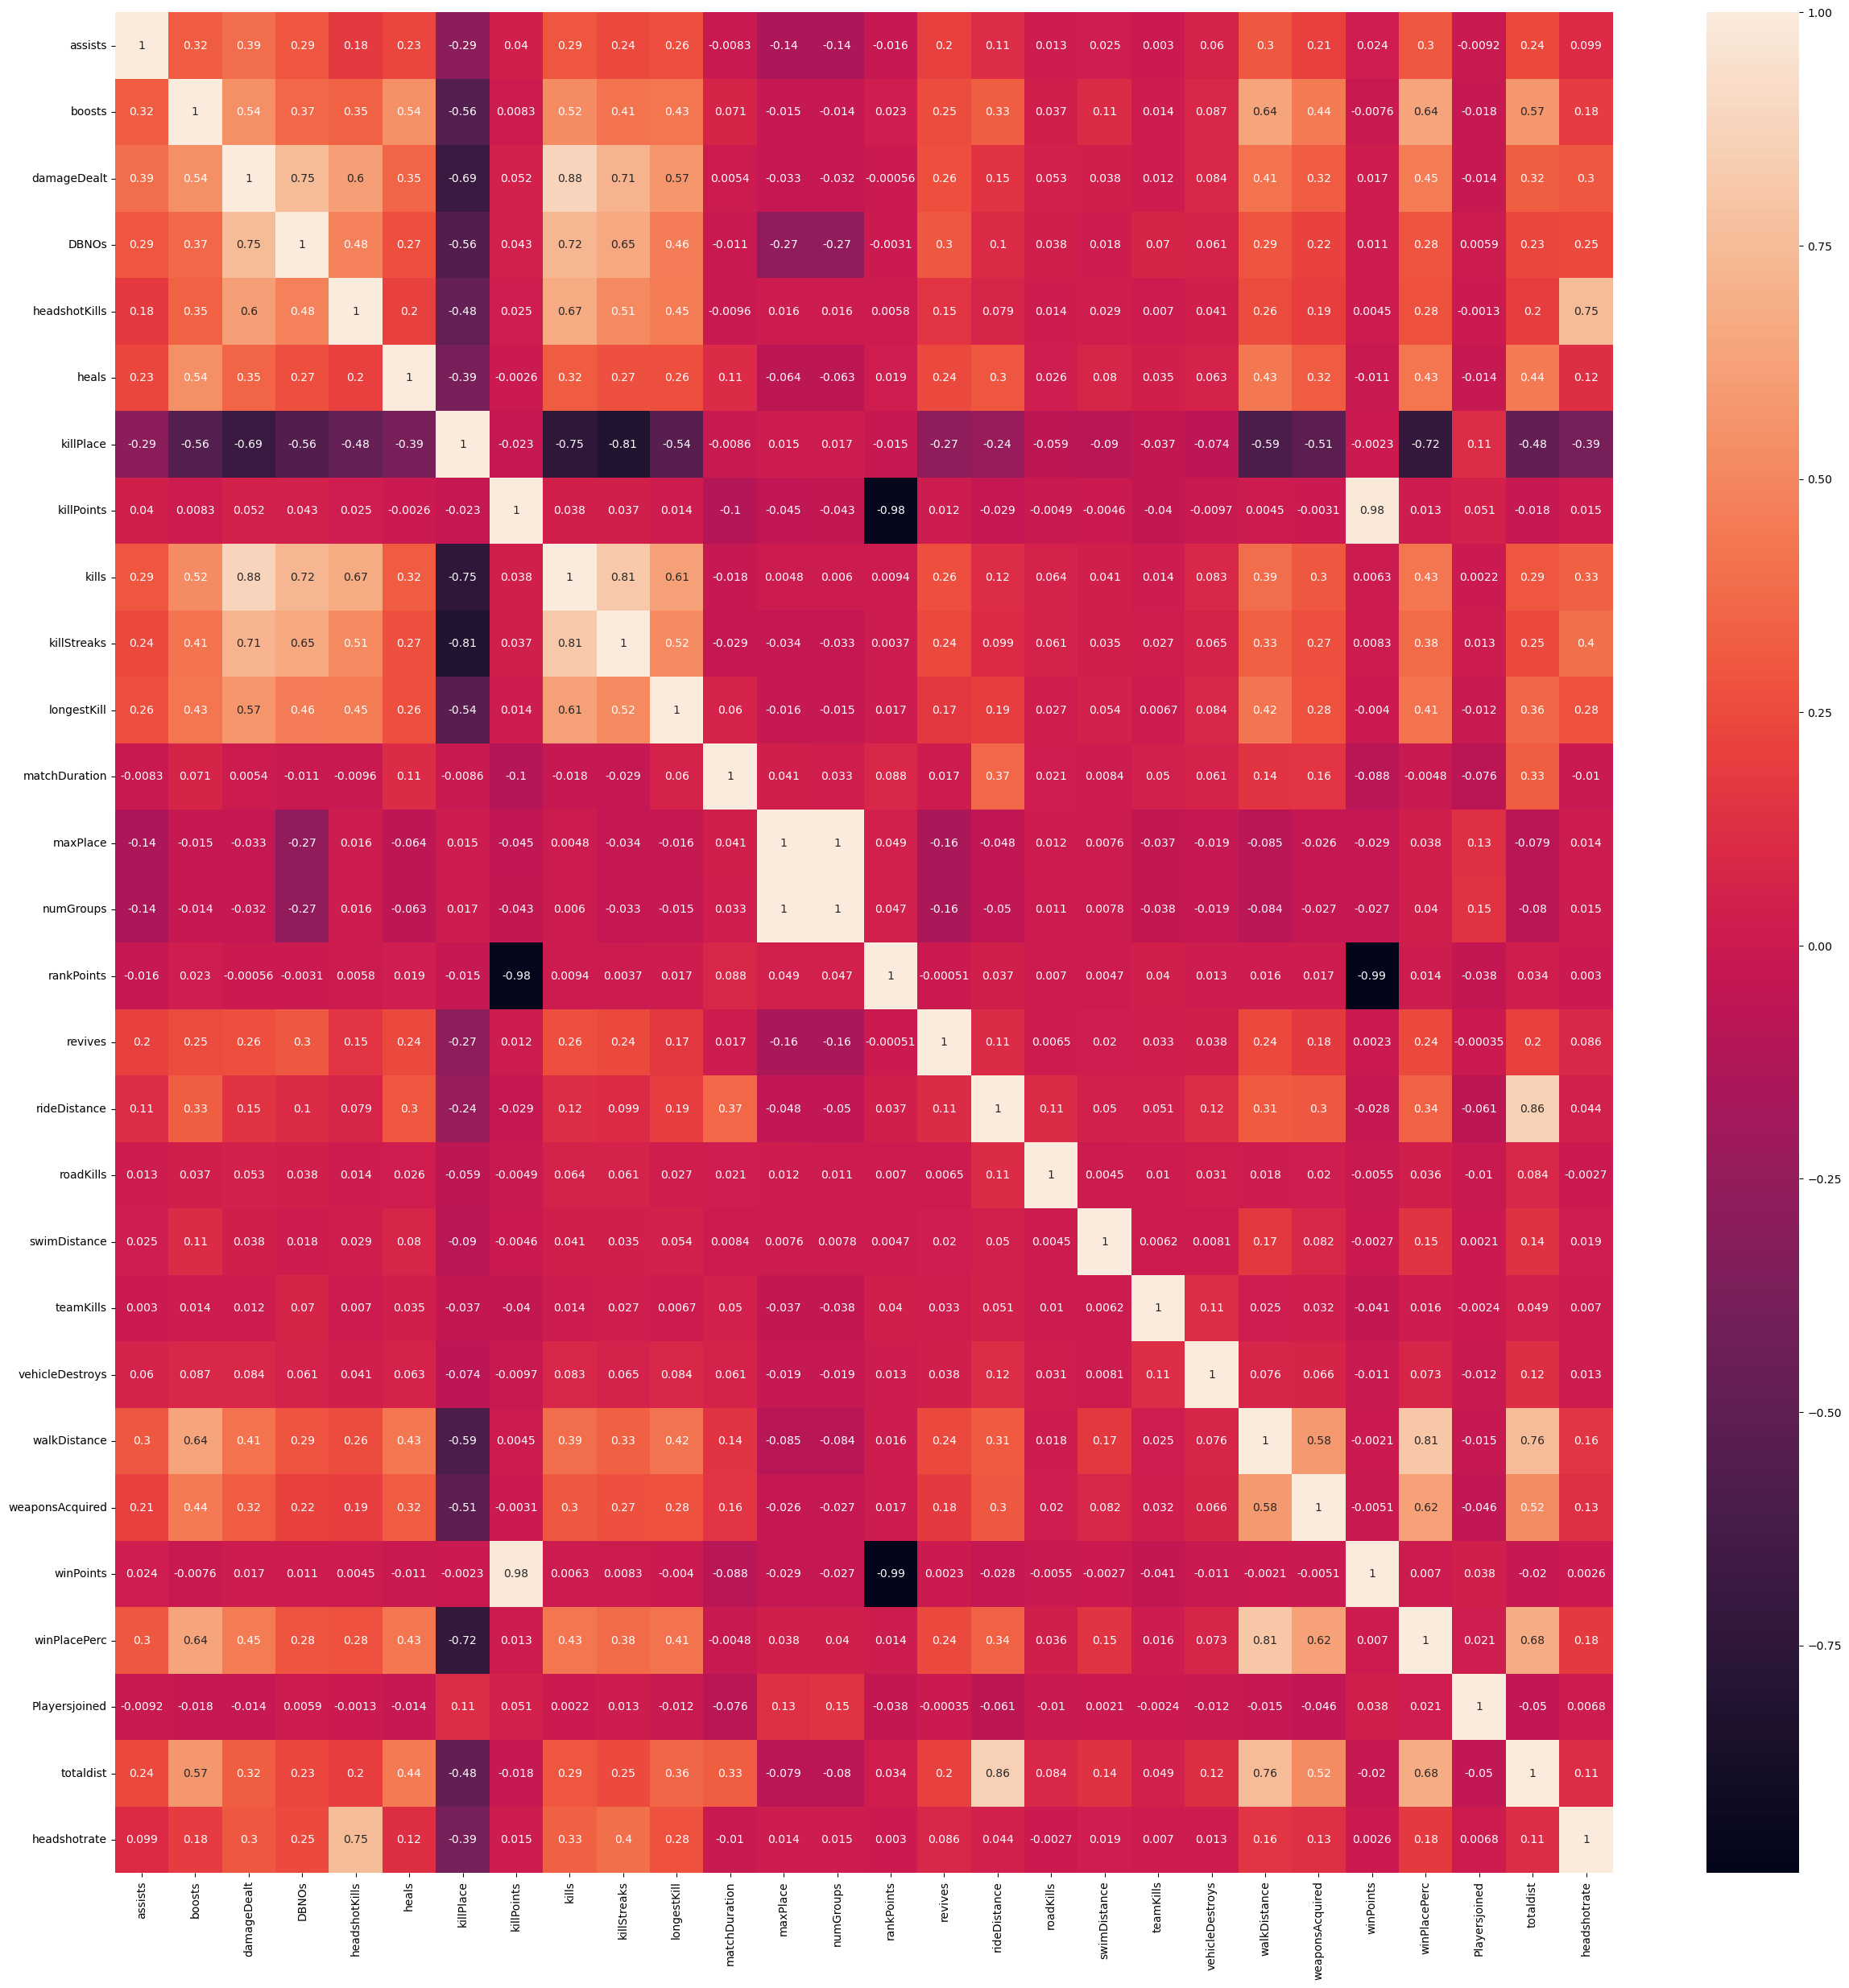

In [82]:
plt.figure(figsize=[30,30])
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),annot=True)
plt.show()

## Feature Engineering

In [95]:
normalize_factor=(100-df["Playersjoined"]/100 )+1

In [97]:
normalize_factor

0          100.04
1          100.09
2          100.02
3          100.09
4          100.03
            ...  
4446961    100.06
4446962    100.07
4446963    100.02
4446964    100.06
4446965    100.02
Name: Playersjoined, Length: 4437940, dtype: float64

In [116]:
df["killsNorm"]=df["kills"]*normalize_factor
df["damageDealtNorm"]=df["damageDealt"]*normalize_factor
df["maxPlaceNorm"]=df["maxPlace"]*normalize_factor
df["matchDurationNorm"]=df["matchDuration"]*normalize_factor

df["travel_dist"]=df["walkDistance"]+df["rideDistance"]+df["swimDistance"]
df["heals_nboost"]=df["heals"]+df["boosts"]
df["assist"]=df["assists"]+df["revives"]

In [197]:
data=df.drop(columns=["Id","groupId","matchId","assists","boosts","walkDistance",
                      "swimDistance","rideDistance","heals","revives","kills",
                     "damageDealt","maxPlace","matchDuration"])

In [199]:
data.head()

,DBNOs,headshotKills,killPlace,killPoints,killStreaks,longestKill,matchType,numGroups,rankPoints,roadKills,...,totaldist,killwithoutmoving,headshotrate,killsNorm,damageDealtNorm,maxPlaceNorm,matchDurationNorm,travel_dist,heals_nboost,assist
0,0,0,60,1241,0,0.00,squad-fpp,26,-1,0,...,244.8000,False,0.0,0.00,0.0000,2801.12,130652.24,244.8000,0,0
1,0,0,57,0,0,0.00,squad-fpp,25,1484,0,...,1445.0445,False,0.0,0.00,9155.2323,2602.34,177859.93,1445.0445,0,0
2,0,0,47,0,0,0.00,duo,47,1491,0,...,161.8000,False,0.0,0.00,6801.3600,5001.00,131826.36,161.8000,0,1
3,0,0,75,0,0,0.00,squad-fpp,30,1408,0,...,202.7000,False,0.0,0.00,3292.9610,3102.79,143729.24,202.7000,0,0
4,0,0,45,0,1,58.53,solo-fpp,95,1560,0,...,49.7500,False,0.0,100.03,10003.0000,9702.91,142442.72,49.7500,0,0


## ML_Catbost Model

## Handling Categorical Data

In [203]:
x=data.drop(["winPlacePerc"],axis=1)
y=data["winPlacePerc"]

In [205]:
x=pd.get_dummies(x,columns=["matchType","killwithoutmoving"])

In [206]:
x.head()

,DBNOs,headshotKills,killPlace,killPoints,killStreaks,longestKill,numGroups,rankPoints,roadKills,teamKills,...,matchType_normal-duo-fpp,matchType_normal-solo,matchType_normal-solo-fpp,matchType_normal-squad,matchType_normal-squad-fpp,matchType_solo,matchType_solo-fpp,matchType_squad,matchType_squad-fpp,killwithoutmoving_False
0,0,0,60,1241,0,0.00,26,-1,0,0,...,False,False,False,False,False,False,False,False,True,True
1,0,0,57,0,0,0.00,25,1484,0,0,...,False,False,False,False,False,False,False,False,True,True
2,0,0,47,0,0,0.00,47,1491,0,0,...,False,False,False,False,False,False,False,False,False,True
3,0,0,75,0,0,0.00,30,1408,0,0,...,False,False,False,False,False,False,False,False,True,True
4,0,0,45,0,1,58.53,95,1560,0,0,...,False,False,False,False,False,False,True,False,False,True


In [209]:
data["matchType"].value_counts()

matchType
squad-fpp           1755308
duo-fpp              996200
squad                625928
solo-fpp             536280
duo                  313329
solo                 181515
normal-squad-fpp      13099
crashfpp               6274
normal-duo-fpp         5006
flaretpp               2500
normal-solo-fpp         845
flarefpp                717
crashtpp                367
normal-squad            305
normal-duo              144
normal-solo             123
Name: count, dtype: int64

In [211]:
x.shape

(4437940, 40)

In [213]:
feature=x.columns

In [215]:
feature

Index(['DBNOs', 'headshotKills', 'killPlace', 'killPoints', 'killStreaks',
       'longestKill', 'numGroups', 'rankPoints', 'roadKills', 'teamKills',
       'vehicleDestroys', 'weaponsAcquired', 'winPoints', 'Playersjoined',
       'totaldist', 'headshotrate', 'killsNorm', 'damageDealtNorm',
       'maxPlaceNorm', 'matchDurationNorm', 'travel_dist', 'heals_nboost',
       'assist', 'matchType_crashfpp', 'matchType_crashtpp', 'matchType_duo',
       'matchType_duo-fpp', 'matchType_flarefpp', 'matchType_flaretpp',
       'matchType_normal-duo', 'matchType_normal-duo-fpp',
       'matchType_normal-solo', 'matchType_normal-solo-fpp',
       'matchType_normal-squad', 'matchType_normal-squad-fpp',
       'matchType_solo', 'matchType_solo-fpp', 'matchType_squad',
       'matchType_squad-fpp', 'killwithoutmoving_False'],
      dtype='object')

In [228]:
sc=StandardScaler()
sc.fit(x)  #in this it calc mean and std div
x=pd.DataFrame(sc.transform(x)) # in this it applies the mean and std div

In [257]:
x.head()

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,-0.581663,-0.38281,0.449778,1.172392,-0.765291,-0.451048,-0.732785,-1.212339,-0.049621,-0.142533,...,-0.033605,-0.005265,-0.0138,-0.00829,-0.054409,-0.206507,-0.370741,-0.405215,1.236243,0.0
1,-0.581663,-0.38281,0.340511,-0.804757,-0.765291,-0.451048,-0.775761,0.803577,-0.049621,-0.142533,...,-0.033605,-0.005265,-0.0138,-0.00829,-0.054409,-0.206507,-0.370741,-0.405215,1.236243,0.0
2,-0.581663,-0.38281,-0.023710,-0.804757,-0.765291,-0.451048,0.169711,0.813079,-0.049621,-0.142533,...,-0.033605,-0.005265,-0.0138,-0.00829,-0.054409,-0.206507,-0.370741,-0.405215,-0.808902,0.0
3,-0.581663,-0.38281,0.996109,-0.804757,-0.765291,-0.451048,-0.560881,0.700405,-0.049621,-0.142533,...,-0.033605,-0.005265,-0.0138,-0.00829,-0.054409,-0.206507,-0.370741,-0.405215,1.236243,0.0
4,-0.581663,-0.38281,-0.096554,-0.804757,0.646735,0.702125,2.232558,0.906748,-0.049621,-0.142533,...,-0.033605,-0.005265,-0.0138,-0.00829,-0.054409,-0.206507,2.697298,-0.405215,-0.808902,0.0


## Splitting Data

In [233]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [234]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape,)

(3106558, 40) (3106558,)
(1331382, 40) (1331382,)


# <font color="green">CatBoost Model</font><a class= "anchor" id="CatBoostModel"></a>

In [236]:
import catboost as cb

In [237]:
train_dataset=cb.Pool(x_train,y_train)
test_dataset=cb.Pool(x_test,y_test)

In [238]:
model=cb.CatBoostRegressor(loss_function="RMSE")

In [244]:
grid={'iterations':[100,150],
     'learning_rate':[0.03,0.1],
     'depth':[2,4,6,8]}

model.grid_search(grid,train_dataset)

0:	learn: 0.5482029	test: 0.5488030	best: 0.5488030 (0)	total: 94ms	remaining: 9.31s
1:	learn: 0.5333545	test: 0.5339448	best: 0.5339448 (1)	total: 183ms	remaining: 8.97s
2:	learn: 0.5189816	test: 0.5195650	best: 0.5195650 (2)	total: 273ms	remaining: 8.82s
3:	learn: 0.5050898	test: 0.5056639	best: 0.5056639 (3)	total: 365ms	remaining: 8.76s
4:	learn: 0.4916624	test: 0.4922262	best: 0.4922262 (4)	total: 462ms	remaining: 8.77s
5:	learn: 0.4786341	test: 0.4791895	best: 0.4791895 (5)	total: 552ms	remaining: 8.64s
6:	learn: 0.4660788	test: 0.4666253	best: 0.4666253 (6)	total: 648ms	remaining: 8.61s
7:	learn: 0.4538895	test: 0.4544280	best: 0.4544280 (7)	total: 740ms	remaining: 8.51s
8:	learn: 0.4420957	test: 0.4426263	best: 0.4426263 (8)	total: 831ms	remaining: 8.4s
9:	learn: 0.4306588	test: 0.4311845	best: 0.4311845 (9)	total: 925ms	remaining: 8.32s
10:	learn: 0.4196154	test: 0.4201365	best: 0.4201365 (10)	total: 1.01s	remaining: 8.2s
11:	learn: 0.4089277	test: 0.4094403	best: 0.4094403 (1

{'params': {'depth': 8, 'learning_rate': 0.1, 'iterations': 150},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39,
               40,
               41,
               42,
               43,
               44,
               45,
               46,
    

In [246]:
feature_imp_df=pd.DataFrame()
feature_imp_df["features"]=feature
feature_imp_df["imp"]=model.feature_importances_

In [248]:
feature_imp_df=feature_imp_df.sort_values(by='imp',ascending=False)

In [250]:
feature_imp_df

,features,imp
2,killPlace,41.731943
14,totaldist,14.707099
16,killsNorm,9.767289
20,travel_dist,9.328368
19,matchDurationNorm,5.033029
4,killStreaks,4.829167
13,Playersjoined,4.671830
5,longestKill,2.182968
21,heals_nboost,1.896377
6,numGroups,1.686162


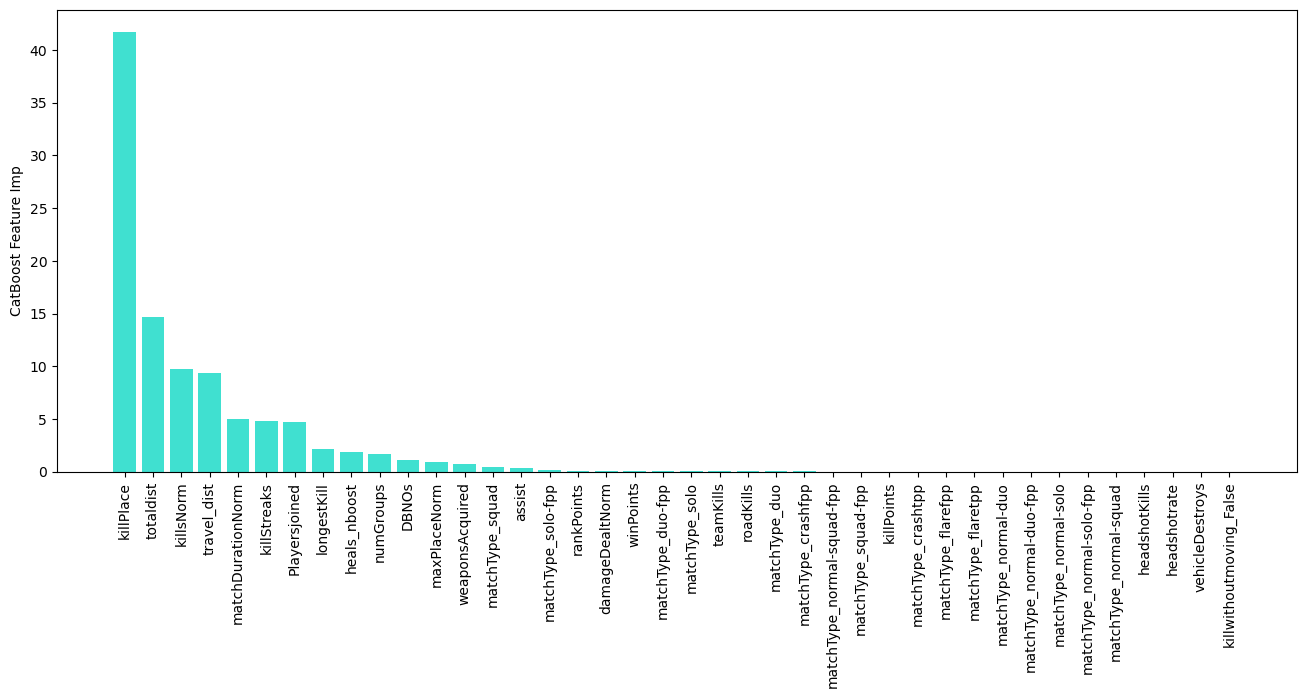

In [252]:
plt.bar(feature_imp_df.features,feature_imp_df.imp,color="turquoise")
plt.ylabel("CatBoost Feature Imp")
plt.xticks(rotation=90)
plt.show()

## Predictions

In [267]:
pred=model.predict(x_test)

In [273]:
rmse=np.sqrt(mean_squared_error(y_test,pred))
r2=r2_score(y_test,pred)

print("Performance")
print("RMSE: {:.2f}".format(rmse))
print("RMSE: {:.2f}".format(r2))

Performance
RMSE: 0.08
RMSE: 0.93
